In [9]:
import numpy as np
import mahotas as mh

from os import walk, path

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import scale
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


In [10]:
# Load dataset
digits = load_digits()

X = digits.data
y = digits.target

# Normalize data
X = scale(X)

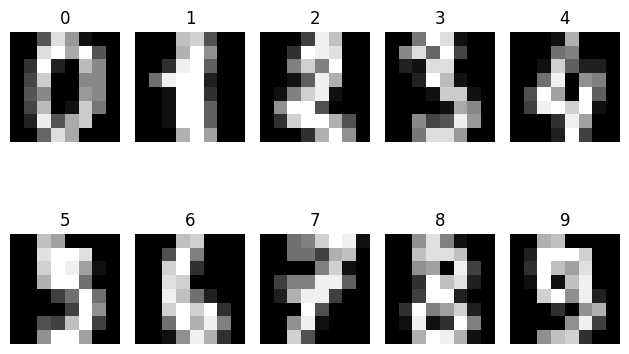

In [19]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

digits = load_digits()

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(digits.images[i], cmap="gray")
    plt.title(digits.target[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [20]:
from sklearn.datasets import load_digits

digits = load_digits()

print(digits.data[0])
print("Label:", digits.target[0])

[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]
Label: 0


In [ ]:

### Create empty lists
X = []
y = []

# Load images
for dir_path, dir_names, file_names in walk("data/att-faces/orl_faces"):

    for fn in file_names:

        if fn.endswith(".pgm"):

            image_filename = path.join(dir_path, fn)

            # Read image
            image = mh.imread(
                image_filename,
                as_grey=True
            )

            # Convert image into vector
            image_vector = image.reshape(10304).astype("float32")

            # Normalize data
            image_vector = scale(image_vector)

            # Store data
            X.append(image_vector)
            y.append(dir_path)


In [5]:
# Convert to NumPy arrays
X = np.array(X)
y = np.array(y)

In [11]:
print(len(X))
print(len(y))

1797
1797


In [12]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)


In [14]:

# Create PCA model
pca = PCA(n_components=20)

# Reduce dimensions
X_train_reduced = pca.fit_transform(X_train)
X_test_reduced = pca.transform(X_test)


In [15]:
# Show dimensions
print("Original training dimensions:", X_train.shape)
print("Reduced training dimensions:", X_train_reduced.shape)

Original training dimensions: (1347, 64)
Reduced training dimensions: (1347, 20)


In [16]:
classifier = LogisticRegression(max_iter=1000)
classifier.fit(X_train_reduced, y_train)
predictions = classifier.predict(X_test_reduced)

In [17]:
# Cross validation
accuracies = cross_val_score(
    classifier,
    X_train_reduced,
    y_train,
    cv=5
)

print("Cross validation accuracy:")
print(np.mean(accuracies))
print(accuracies)

# Evaluation report
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        predictions
    )
)


Cross validation accuracy:
0.9279884345311855
[0.91851852 0.93703704 0.92936803 0.94423792 0.91078067]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        43
           1       0.89      0.86      0.88        37
           2       0.88      0.92      0.90        38
           3       0.93      0.89      0.91        46
           4       0.95      0.96      0.95        55
           5       0.95      0.92      0.93        59
           6       0.96      0.98      0.97        45
           7       1.00      0.98      0.99        41
           8       0.86      0.97      0.91        38
           9       0.89      0.85      0.87        48

    accuracy                           0.93       450
   macro avg       0.93      0.93      0.93       450
weighted avg       0.93      0.93      0.93       450

